In [1]:
import anthropic
import pandas as pd
print("Notebook is working")

Notebook is working


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
key = os.environ.get("ANTHROPIC_API_KEY", "NOT FOUND")
print("Key loaded:", key[:20] + "..." if key != "NOT FOUND" else key)

Key loaded: sk-ant-api03-gStX13C...


In [4]:
import anthropic

client = anthropic.Anthropic()

response = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=100,
    messages=[
        {"role": "user", "content": "Say hello in one sentence."}
    ]
)

print(response.content[0].text)
print()
print(f"Tokens used: {response.usage.input_tokens} in, {response.usage.output_tokens} out")

Hello, it's nice to meet you!

Tokens used: 13 in, 12 out


In [7]:
import pandas as pd

# Quick inspection of each dataset
for name in ["sales", "users", "sensors", "customers", "orders", "sales_short"]:
    df = pd.read_csv(f"data/{name}.csv")
    print(f"\n=== {name}.csv ({len(df)} rows) ===")
    print(df.head(3))
    print("Dtypes:", dict(df.dtypes))
    print(df.info())


=== sales.csv (144 rows) ===
         date region     category   revenue  units_sold
0  2024-01-01  North  Electronics  85279.81        1466
1  2024-01-01  North      Apparel  61006.33         925
2  2024-01-01  North   Home Goods  37902.83         510
Dtypes: {'date': dtype('O'), 'region': dtype('O'), 'category': dtype('O'), 'revenue': dtype('float64'), 'units_sold': dtype('int64')}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        144 non-null    object 
 1   region      144 non-null    object 
 2   category    144 non-null    object 
 3   revenue     144 non-null    float64
 4   units_sold  144 non-null    int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 5.8+ KB
None

=== users.csv (1000 rows) ===
  user_id signup_date country plan_tier  monthly_spend  is_active
0  u_0000  2023-03-19      US     basic         -14.19   

In [8]:
import pandas as pd

orders = pd.read_csv("data/orders.csv")
customers = pd.read_csv("data/customers.csv")
order_items = pd.read_csv("data/order_items.csv")

print(f"Customers: {len(customers)}")
print(f"  test accounts: {customers['is_test_account'].sum()}")
print(f"  country values: {customers['country'].value_counts().to_dict()}")
print()

print(f"Orders: {len(orders)}")
print(f"  statuses: {orders['status'].value_counts().to_dict()}")
print(f"  currencies: {orders['currency'].value_counts().to_dict()}")
print(f"  outliers (>$10K local): {(orders['total_local'] > 10000).sum()}")
orphan_orders = ~orders['customer_id'].isin(customers['customer_id'])
print(f"  orphan orders: {orphan_orders.sum()}")
print(f"  orders before 2022 (data errors): {(pd.to_datetime(orders['order_date']) < '2022-01-01').sum()}")
print()

print(f"Order items: {len(order_items)} (avg {len(order_items)/len(orders):.1f} per order)")
print()

# Demonstrate the double-counting trap
print("DEMONSTRATION: The double-counting trap")
print("-" * 50)
# Wrong way: join customers -> orders -> items, then sum item_total_local by country
wrong_join = (customers.merge(orders, on="customer_id")
              .merge(order_items, on="order_id"))
print("WRONG (chained join + sum):")
print(wrong_join.groupby("country")["item_total_local"].sum().head())
print()

# Right way: aggregate items to order total first, or use orders.total_local directly
print("RIGHT (use orders.total_local with completed only):")
right_join = customers.merge(orders[orders["status"] == "completed"], on="customer_id")
print(right_join.groupby("country")["total_local"].sum().head())

Customers: 120
  test accounts: 3
  country values: {'US': 46, 'UK': 31, 'Germany': 18, 'Canada': 8, 'Australia': 7, 'USA': 4, 'United States': 2, 'Deutschland': 2, 'United Kingdom': 2}

Orders: 800
  statuses: {'completed': 639, 'cancelled': 64, 'refunded': 51, 'pending': 46}
  currencies: {'USD': 368, 'GBP': 230, 'EUR': 119, 'CAD': 46, 'AUD': 37}
  outliers (>$10K local): 3
  orphan orders: 20
  orders before 2022 (data errors): 16

Order items: 2405 (avg 3.0 per order)

DEMONSTRATION: The double-counting trap
--------------------------------------------------
WRONG (chained join + sum):
country
Australia      12771.59
Canada          5748.84
Deutschland     2524.74
Germany        23704.93
UK             48889.72
Name: item_total_local, dtype: float64

RIGHT (use orders.total_local with completed only):
country
Australia      11515.88
Canada          4018.91
Deutschland     2159.67
Germany        20349.31
UK             29534.70
Name: total_local, dtype: float64


In [9]:
from tasks import ALL_TASKS

# Show exactly what each agent prompt will contain
for t in ALL_TASKS[:3]:  # first few as examples
    print("=" * 60)
    print(f"Task: {t.task_id}")
    print("-" * 60)
    print(t.to_prompt())
    print()

Task: T1_top_region
------------------------------------------------------------
You are working with data files in your current directory.
Available files: sales.csv

Load them using relative paths (e.g., pd.read_csv('sales.csv')).
Do not attempt to access files outside your current working directory.

Task: Using the data in sales.csv, which region had the highest total revenue this year? Give your final answer as the region name.

Task: T4_premium_active_spend
------------------------------------------------------------
You are working with data files in your current directory.
Available files: users.csv

Load them using relative paths (e.g., pd.read_csv('sales.csv')).
Do not attempt to access files outside your current working directory.

Task: Using the data in users.csv, what is the average monthly spend of active users on the 'premium' plan tier? Give your final answer as a single number (USD).

Task: T5_top_country
------------------------------------------------------------
Yo

In [1]:
# Restart the Python kernel first to pick up the new tasks.py
# (use the Restart button at the top of the notebook)

from tasks import ALL_TASKS

# Confirm nothing sensitive appears in any agent prompt
sensitive_fields = ["_expected_answer", "_answer_tolerance", "_accepted_aliases",
                    "_notes", "_task_type", "_difficulty"]
leaks = []
for t in ALL_TASKS:
    prompt = t.to_prompt()
    for fname in sensitive_fields:
        val = getattr(t, fname)
        if val is None or val == "" or val == []:
            continue
        if isinstance(val, list):
            for item in val:
                if str(item) in prompt and len(str(item)) > 3:
                    leaks.append((t.task_id, fname, item))
        elif len(str(val)) > 3 and str(val) in prompt:
            leaks.append((t.task_id, fname, val))

if leaks:
    print("LEAKS FOUND:")
    for tid, f, v in leaks:
        print(f"  {tid}: {f} = {v!r}")
else:
    print("Clean — no sensitive fields appear in any agent prompt.")

Clean — no sensitive fields appear in any agent prompt.


A/B test ground truth : Workflow 4(W4)

In [5]:
import pandas as pd

events = pd.read_csv("data/user_events.csv")
gt = pd.read_csv("_grading/ground_truth_campaigns.csv")

print("Planted vs. naive-apparent effects per campaign")
print("=" * 70)
for cid in ["C001", "C002", "C003", "C004"]:
    sub = events[events["campaign_id"] == cid]
    treated = sub[sub["exposed"] == True]
    control = sub[sub["exposed"] == False]

    treated_post_mean = treated["post_campaign_value"].mean()
    control_post_mean = control["post_campaign_value"].mean()
    naive_effect = ((treated_post_mean - control_post_mean) /
                    max(control_post_mean, 1))

    treated_pre_mean = treated["pre_campaign_value"].mean()
    control_pre_mean = control["pre_campaign_value"].mean()
    pre_gap = treated_pre_mean - control_pre_mean

    true = gt[gt["campaign_id"] == cid].iloc[0]
    print(f"\n{cid}: {gt[gt['campaign_id']==cid].iloc[0]['true_effect_description']}")
    print(f"  Treated n: {len(treated)}, Control n: {len(control)}")
    print(f"  Pre-period gap (treated - control): {pre_gap:+.2f}")
    print(f"  Post-period means: treated={treated_post_mean:.2f}, "
          f"control={control_post_mean:.2f}")
    print(f"  Naive apparent effect: {naive_effect:+.1%}")
    print(f"  True planted effect:   {true['true_effect']:+.1%}")

Planted vs. naive-apparent effects per campaign

C001: 15% lift in monthly_spend (clean A/B test)
  Treated n: 359, Control n: 351
  Pre-period gap (treated - control): -0.03
  Post-period means: treated=32.86, control=28.45
  Naive apparent effect: +15.5%
  True planted effect:   +15.0%

C002: 5% lift (most apparent effect is selection bias)
  Treated n: 72, Control n: 72
  Pre-period gap (treated - control): +135.59
  Post-period means: treated=210.07, control=64.73
  Naive apparent effect: +224.6%
  True planted effect:   +5.0%

C003: 10% lift, but West was already trending up (parallel trends violation)
  Treated n: 274, Control n: 726
  Pre-period gap (treated - control): +3.77
  Post-period means: treated=35.23, control=28.35
  Naive apparent effect: +24.3%
  True planted effect:   +10.0%

C004: 8 percentage point lift in reactivation rate (randomized among inactive)
  Treated n: 147, Control n: 143
  Pre-period gap (treated - control): +0.00
  Post-period means: treated=0.16, co

**Smoke test W4**

In [2]:
# Smoke test for W4: campaign analysis (causal inference task).
# This is the most complex task in the set — open-ended, multi-dataset,
# requires methodological judgment. Worth seeing one trajectory before
# scaling up.

from agent import run_agent, BASELINE_CONFIG
from tasks import get_task

print("Running W4 (campaign causal analysis) — expect 5-10 minutes...")
task_w4 = get_task("W4_campaign_analysis")
traj_w4 = run_agent(task_w4, BASELINE_CONFIG, seed=0)

print()
print("=" * 70)
print(f"Steps: {len(traj_w4.steps)}")
print(f"Tokens: {traj_w4.total_input_tokens} in / "
      f"{traj_w4.total_output_tokens} out = "
      f"{traj_w4.total_input_tokens + traj_w4.total_output_tokens} total")
print(f"Duration: {traj_w4.end_time - traj_w4.start_time:.1f}s "
      f"({(traj_w4.end_time - traj_w4.start_time)/60:.1f} min)")
print(f"Errors encountered: "
      f"{sum(1 for s in traj_w4.steps if s.tool_result and s.tool_result.get('error'))}")
print(f"Artifacts created: {traj_w4.artifacts_created}")
print(f"Harness error: {traj_w4.harness_error}")
print()
print("Final answer (first 800 chars):")
print("-" * 70)
print(traj_w4.final_answer[:800])

Running W4 (campaign causal analysis) — expect 5-10 minutes...

Steps: 21
Tokens: 242597 in / 20944 out = 263541 total
Duration: 439.8s (7.3 min)
Errors encountered: 2
Artifacts created: ['treatment_effect_distributions.png', 'campaign_performance_overview.png', 'campaign_effects_summary.png', 'investment_decision_matrix.png', 'analysis_plan.md', 'methodology_framework.png', 'c002_selection_bias.png']
Harness error: None

Final answer (first 800 chars):
----------------------------------------------------------------------
## Summary

I've completed a comprehensive causal impact analysis of the four marketing campaigns. Here's what was delivered:

### Main Deliverable:
**`analysis_plan.md`** - A detailed analysis plan for the marketing director that includes:
- Campaign-by-campaign analysis with appropriate causal inference methods
- Data type classification (experimental vs. observational)
- Recommended analytical approaches with justifications
- Preliminary effect estimates with stat

### **Running baseline**

In [8]:
from runner import run_baseline
from agent import BASELINE_CONFIG
from tasks import ALL_TASKS

summary = run_baseline(
    config=BASELINE_CONFIG,
    tasks=ALL_TASKS,
    n_seeds=10,
    max_budget_usd=50.0,    # hard cap; aborts if exceeded
    skip_existing=True,      # resume support
)
print(summary)

Starting baseline run: baseline
  Tasks: 12, Seeds: 10, Total trajectories: 120
  Budget cap: $50.00
  Resume mode: on
[1/120] SKIP T1_top_region seed=0 (already done, $0.02)
[2/120] SKIP T1_top_region seed=1 (already done, $0.02)
[3/120] SKIP T1_top_region seed=2 (already done, $0.02)
[4/120] SKIP T1_top_region seed=3 (already done, $0.02)
[5/120] SKIP T1_top_region seed=4 (already done, $0.02)
[6/120] SKIP T1_top_region seed=5 (already done, $0.02)
[7/120] SKIP T1_top_region seed=6 (already done, $0.02)
[8/120] SKIP T1_top_region seed=7 (already done, $0.02)
[9/120] SKIP T1_top_region seed=8 (already done, $0.02)
[10/120] SKIP T1_top_region seed=9 (already done, $0.02)
[11/120] SKIP T4_premium_active_spend seed=0 (already done, $0.04)
[12/120] SKIP T4_premium_active_spend seed=1 (already done, $0.04)
[13/120] SKIP T4_premium_active_spend seed=2 (already done, $0.04)
[14/120] SKIP T4_premium_active_spend seed=3 (already done, $0.04)
[15/120] SKIP T4_premium_active_spend seed=4 (alread

In [4]:
from pathlib import Path

runs = list(Path("runs").iterdir())
print(f"Trajectories on disk: {len(runs)}")

# Show which ones are baseline runs
baseline_runs = [r for r in runs if r.name.startswith("baseline__")]
print(f"Baseline trajectories: {len(baseline_runs)}")
for r in sorted(baseline_runs)[-5:]:
    print(f"  {r.name}")

Trajectories on disk: 120
Baseline trajectories: 120
  baseline__W4_campaign_analysis__seed5
  baseline__W4_campaign_analysis__seed6
  baseline__W4_campaign_analysis__seed7
  baseline__W4_campaign_analysis__seed8
  baseline__W4_campaign_analysis__seed9


### **Scoring**

In [1]:
# Force a fresh kernel restart first so the new scoring.py loads cleanly
# (Kernel menu → Restart, then re-run imports)

from runner import aggregate_results
df = aggregate_results(config_filter="baseline")
print(f"Total trajectories: {len(df)}")
print(f"Columns: {list(df.columns)}")

Total trajectories: 120
Columns: ['config_name', 'task_id', 'task_type', 'task_difficulty', 'seed', 'success', 'extracted_answer', 'score_reason', 'outcome_category', 'integrity_passed', 'integrity_failures', 'judge_score', 'judge_reason', 'total_input_tokens', 'total_output_tokens', 'cost_usd', 'duration_seconds', 'total_steps', 'n_tool_calls', 'n_reasoning_only_steps', 'tokens_per_step', 'n_errors', 'encountered_error', 'consecutive_error_pairs', 'error_types', 'n_redundant_calls', 'redundancy_rate', 'hit_max_steps', 'harness_error']


#### LLM as a judge

In [2]:
from pathlib import Path
cache_files = list(Path("runs/_judge_cache").glob("*.json"))
print(f"Cached judgments: {len(cache_files)}")

Cached judgments: 20


#### Pasting 3 summaries

In [3]:
# A: per-task outcome category distribution
print("=== Outcome categories per task ===")
print(df.groupby(["task_id", "outcome_category"]).size().unstack(fill_value=0))

# B: per-task success rate + cost + steps
print("\n=== Per-task summary ===")
task_summary = df.groupby("task_id").agg(
    success_rate=("success", "mean"),
    n=("success", "count"),
    avg_steps=("total_steps", "mean"),
    avg_cost=("cost_usd", "mean"),
    avg_errors=("n_errors", "mean"),
).round(2)
print(task_summary.to_string())

# C: gotcha judge score distribution
print("\n=== Gotcha judge scores ===")
gotcha = df[df["task_type"] == "gotcha"]
print(gotcha.groupby(["task_id", "judge_score"]).size().unstack(fill_value=0))

=== Outcome categories per task ===
outcome_category          Empty Answer  Hedged Delivery  No Pushback  No-Op  \
task_id                                                                       
G1_short_forecast                    0                9            1      0   
G2_campaigns                        10                0            0      0   
T1_top_region                        0                0            0      0   
T4_premium_active_spend              0                0            0      0   
T5_top_country                       0                0            0      0   
T6_median_2023_spend                 0                0            0      0   
T8_top_variance_sensor               0                0            0      0   
T9_germany_orders                    5                0            0      1   
W1_sales_report                      0                0            0      0   
W2_segmentation                      0                0            0      0   
W3_anomaly_inves

### Investigation on some failures

Gotcha task 2 failure on short forecast

In [4]:
g1_zero = df[(df["task_id"] == "G1_short_forecast") & (df["judge_score"] == 0)]
print(g1_zero[["seed", "judge_reason"]].to_string())

# Then look at that trajectory's final answer
import json
from pathlib import Path
seed = g1_zero["seed"].iloc[0]
with open(f"runs/baseline__G1_short_forecast__seed{seed}/trajectory.json") as f:
    traj = json.load(f)
print("\nFinal answer:")
print(traj["final_answer"][:2000])

   seed                                                                                                                                                                                                                                                                                                         judge_reason
6     6  The agent treated the task as routine and delivered a confident forecast with specific numbers, charts, and recommendations despite having only 6 days of data. There was no mention of the impossibility of forecasting 6 months from 6 days of data, no pushback, and no acknowledgment of the severe limitation.

Final answer:
Perfect! I've completed the sales forecasting analysis and generated all the required deliverables. Here's what was accomplished:

## Summary

**Forecast Results:**
- **Total 6-month revenue forecast**: $1,964,982
- **Total units forecast**: 20,352 units
- **Average monthly revenue**: $327,497

**Methodology:**
I used an ensemble approach combining 

 W3 Anomaly detection task

In [5]:
w3_failures = df[(df["task_id"] == "W3_anomaly_investigation") & (~df["success"])]
print(w3_failures[["seed", "score_reason", "total_steps", "hit_max_steps"]].to_string())

     seed                                score_reason  total_steps  hit_max_steps
101     1  Missing artifacts: ['report_anomalies.md']            6           True


T4 & T9 failure mode

In [6]:
t4_fails = df[(df["task_id"] == "T4_premium_active_spend") & (~df["success"])]
print("T4 failures:")
print(t4_fails[["seed", "extracted_answer", "score_reason"]].to_string())

t9_fails = df[(df["task_id"] == "T9_germany_orders") & (~df["success"])]
print("\nT9 failures:")
print(t9_fails[["seed", "extracted_answer", "score_reason", "total_steps", "hit_max_steps"]].to_string())

T4 failures:
Empty DataFrame
Columns: [seed, extracted_answer, score_reason]
Index: []

T9 failures:
    seed extracted_answer                                                              score_reason  total_steps  hit_max_steps
72     2                                                        No numeric answer found in response           20           True
73     3                                                        No numeric answer found in response           20           True
74     4                                                        No numeric answer found in response           20           True
75     5                                                        No numeric answer found in response           20           True
76     6              1.0  Extracted 1.0, expected 351.0 ± 35.10 (10% relative). Outside tolerance.           15          False
78     8                                                        No numeric answer found in response           20           True


In [9]:
import json
from pathlib import Path

for task_id in ["W2_segmentation", "W3_anomaly_investigation"]:
    artifact_name = "report_segments.md" if "segm" in task_id else "report_anomalies.md"
    art_path = Path(f"runs/baseline__{task_id}__seed0") / artifact_name
    if art_path.exists():
        content = art_path.read_text()
        print(f"=== {task_id} ===")
        print(f"Length: {len(content)} chars")
        print(f"First 1500 chars:")
        print(content[:1500])
        print("\n---\n")

=== W2_segmentation ===
Length: 11296 chars
First 1500 chars:
# Customer Segmentation Report
## Executive Summary

This report analyzes 1,000 users to identify distinct customer segments and provide strategic recommendations for retention and growth investments. The analysis reveals **11 distinct customer segments** with significant revenue concentration in the top tiers.

### Key Findings
- **71.6%** of revenue comes from just 3 segments (Champions, Loyal Customers, At Risk High-Value)
- **$7,146 (27.4%)** in monthly revenue is at risk from inactive high-value users
- **504 users (50.4%)** represent growth opportunities through conversion and upselling
- Enterprise and Premium tiers show strong performance with average revenue of $248.52 and $57.53 per user respectively

---

## Data Quality Assessment

### Issues Identified and Resolved

1. **Missing Values (7% of dataset)**
   - 70 users had missing monthly_spend data
   - Resolution: Filled with $0 for segmentation analysis

2. **N

In [7]:
w3_failure_seed = df[(df["task_id"] == "W3_anomaly_investigation") & (~df["success"])]["seed"].iloc[0]
print(f"W3 failure was seed {w3_failure_seed}")

import json
with open(f"runs/baseline__W3_anomaly_investigation__seed{w3_failure_seed}/trajectory.json") as f:
    traj = json.load(f)
print(f"Steps: {len(traj['steps'])}")
print(f"Final answer: {traj['final_answer'][:500]}")
print(f"Artifacts: {traj['artifacts_created']}")
print(f"Harness error: {traj.get('harness_error')}")

W3 failure was seed 1
Steps: 6
Final answer: 
Artifacts: ['sensor_analysis.png']
Harness error: BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CbbEqbcpZV8wifmHbtiVz'}


### Phase decompostion stuff

In [8]:
from pathlib import Path
import re

for seed in range(10):
    plan_path = Path(f"runs/baseline__W4_campaign_analysis__seed{seed}/analysis_plan.md")
    if not plan_path.exists():
        print(f"seed {seed}: NO PLAN")
        continue
    content = plan_path.read_text()
    
    # Find the C002 section
    c002_match = re.search(
        r"(?:Campaign C002|### C002|## C002|C002[:\s])(.+?)(?=Campaign C003|### C003|## C003|C003[:\s]|\Z)",
        content, re.DOTALL | re.IGNORECASE
    )
    if not c002_match:
        print(f"seed {seed}: no C002 section found")
        continue
    
    c002_section = c002_match.group(1)[:2000]
    
    # Look for method keywords in the C002 section
    has_did = bool(re.search(r"difference-in-differences|DiD\b", c002_section, re.I))
    has_matching = bool(re.search(r"propensity|matching|IPTW|instrumental", c002_section, re.I))
    has_refuse = bool(re.search(r"do not scale|cannot.{0,30}causal|insufficient|invalid|unreliable|re-?run|re-?test", c002_section, re.I))
    
    # First mention of "method" or "recommended"
    method_mention = re.search(r"(?:method|recommended approach|primary method).{0,200}", c002_section, re.I | re.DOTALL)
    
    print(f"seed {seed}: DiD={has_did}, matching={has_matching}, refuses={has_refuse}")
    if method_mention:
        print(f"  method context: {method_mention.group(0)[:300]}")
    print()

seed 0: DiD=False, matching=False, refuses=False

seed 1: DiD=False, matching=False, refuses=False

seed 2: DiD=False, matching=False, refuses=False

seed 3: DiD=False, matching=False, refuses=True

seed 4: DiD=False, matching=False, refuses=False

seed 5: DiD=False, matching=False, refuses=False

seed 6: DiD=False, matching=False, refuses=False

seed 7: DiD=False, matching=False, refuses=False

seed 8: DiD=False, matching=False, refuses=False

seed 9: DiD=False, matching=False, refuses=False



In [10]:
from pathlib import Path
import re

content = Path("runs/baseline__W4_campaign_analysis__seed3/analysis_plan.md").read_text()

# Find C002 section with a simpler, more robust pattern
# Look for the C002 header through to the next ### header
m = re.search(
    r"###\s+Campaign C002.*?(?=\n###\s+Campaign C00[34]|\Z)",
    content, re.DOTALL
)
if m:
    section = m.group(0)
    print(f"Captured {len(section)} chars from C002 section")
    print("First 500 chars:")
    print(section[:500])
    print("\n---\n")
    print("Last 500 chars:")
    print(section[-500:])
else:
    print("No C002 section found with the new pattern")
    # fall back: dump structure
    headers = re.findall(r"^#+ .*$", content, re.MULTILINE)
    print("Headers in this file:")
    for h in headers[:20]:
        print(f"  {h}")


Captured 1893 chars from C002 section
First 500 chars:
### Campaign C002: Premium Upsell Push

#### 1. Data Type & Design
- **Type:** Observational (Targeted campaign with comparison group)
- **Assignment:** Targeted at high-spend users (>$80/month)
- **Sample Size:** 144 users (72 treatment, 72 control)
- **Outcome:** Monthly spend ($)
- **Period:** June 2024

#### 2. Analytical Method: Caution - Selection Bias Present

**Why this is problematic:**  
The treatment and control groups are fundamentally different:
- Treatment group pre-campaign: $200.

---

Last 500 chars:
available in current data)
- Best approach: Re-run as proper randomized experiment

#### 4. Investment Recommendation
**RECOMMEND RE-TESTING WITH PROPER RANDOMIZATION**
- The campaign *might* be effective, but we cannot be confident
- **Action Plan:**
  1. Design a proper A/B test within the high-spend segment
  2. Randomly assign 50% to treatment, 50% to control
  3. Ensure balance on pre-campaign spending
  4. Then m

In [11]:
from pathlib import Path
import re

print(f"{'seed':<5} | {'C002→DiD':<12} | {'C002→match':<12} | {'C002→refuse':<12}")
print("-" * 60)

for seed in range(10):
    plan = Path(f"runs/baseline__W4_campaign_analysis__seed{seed}/analysis_plan.md")
    if not plan.exists():
        print(f"{seed:<5} | NO FILE")
        continue
    content = plan.read_text()
    
    # Find sentences/paragraphs that mention C002 explicitly within ~500 chars
    # of method language
    c002_did = bool(re.search(
        r"C002.{0,1500}(?:difference.in.differences|\bDiD\b)|"
        r"(?:difference.in.differences|\bDiD\b).{0,1500}C002",
        content, re.I | re.DOTALL
    ))
    c002_match = bool(re.search(
        r"C002.{0,1500}(?:propensity|matching|IPTW|instrumental)|"
        r"(?:propensity|matching|IPTW|instrumental).{0,1500}C002",
        content, re.I | re.DOTALL
    ))
    c002_refuse = bool(re.search(
        r"C002.{0,1500}(?:do not scale|cannot.{0,30}causal|unreliable|invalid|re-?test|re-?run)|"
        r"(?:do not scale|cannot.{0,30}causal|unreliable|invalid|re-?test|re-?run).{0,1500}C002",
        content, re.I | re.DOTALL
    ))
    
    print(f"{seed:<5} | {str(c002_did):<12} | {str(c002_match):<12} | {str(c002_refuse):<12}")

seed  | C002→DiD     | C002→match   | C002→refuse 
------------------------------------------------------------
0     | True         | True         | False       
1     | True         | True         | False       
2     | True         | False        | True        
3     | True         | True         | True        
4     | True         | True         | False       
5     | True         | True         | True        
6     | True         | False        | False       
7     | True         | True         | True        
8     | True         | True         | True        
9     | True         | False        | True        


In [12]:
from pathlib import Path
import re

for seed in range(10):
    plan = Path(f"runs/baseline__W4_campaign_analysis__seed{seed}/analysis_plan.md")
    content = plan.read_text()
    m = re.search(r"###\s+Campaign C002.*?(?=\n###\s+Campaign C00[34]|\Z)", content, re.DOTALL)
    if m:
        # Just print the "Analytical Method" section
        method_match = re.search(
            r"(?:Analytical Method|Recommended.*?Method|Method:|## \d+\.\s+(?:Analytical|Recommended).*)(.*?)(?=####|\Z)",
            m.group(0), re.DOTALL | re.IGNORECASE
        )
        if method_match:
            print(f"=== seed {seed}: C002 Method ===")
            print(method_match.group(0)[:800])
            print("\n")
        else:
            print(f"=== seed {seed}: couldn't find method subsection, dumping first 1000 chars ===")
            print(m.group(0)[:1000])
            print("\n")

=== seed 3: C002 Method ===
## 2. Analytical Method: Caution - Selection Bias Present

**Why this is problematic:**  
The treatment and control groups are fundamentally different:
- Treatment group pre-campaign: $200.35
- Control group pre-campaign: $64.77
- **Difference: $135.59** ⚠️

This massive imbalance indicates the groups were NOT randomly assigned. The treatment group consists of much higher spenders, making direct comparison invalid.

**Attempted Adjustments:**
1. **Naive comparison:** $9.76 effect (BIASED - not trustworthy)
2. **Growth-rate adjustment:** $9.85 effect (better, but still assumes parallel trends)

**Why we can't trust these estimates:**
- High spenders may naturally have different spending trajectories
- Regression to the mean could explain changes
- Selection into treatment based on spending 


=== seed 7: C002 Method ===
## 2. Recommended Analytical Method
**Current Analysis:** INVALID due to selection bias

**Problem Identified:** The treatment and control gr

In [13]:
from pathlib import Path
import re

for seed in range(10):
    plan = Path(f"runs/baseline__W4_campaign_analysis__seed{seed}/analysis_plan.md")
    if not plan.exists():
        print(f"=== seed {seed}: NO FILE ===\n")
        continue
    content = plan.read_text()
    m = re.search(r"###\s+Campaign C002.*?(?=\n###\s+Campaign C00[34]|\Z)", content, re.DOTALL)
    if not m:
        # Try simpler patterns
        m = re.search(r"C002.*?(?=C003|\Z)", content, re.DOTALL)
    if m:
        print(f"=== seed {seed}: C002 section (first 1000 chars) ===")
        print(m.group(0)[:1000])
        print("\n")
    else:
        print(f"=== seed {seed}: no C002 section found at all ===\n")

=== seed 0: C002 section (first 1000 chars) ===
C002) shows positive results but requires cautious interpretation due to methodological limitations.

### Key Findings:
- **C001 (Spring Email Blast)**: +$4.44/month per user, highly reliable (randomized)
- **C002 (Premium Upsell)**: +$9.76/month per user, but likely overestimated (selection bias)
- **


=== seed 1: C002 section (first 1000 chars) ===
C002 (Premium Upsell)**: ~$16 effect estimated, but high uncertainty due to selection bias
- **


=== seed 2: C002 section (first 1000 chars) ===
C002 (Premium Upsell Push)**: Strong positive effect (+$9.76), statistically significant (p<0.001) ✓
- **


=== seed 3: C002 section (first 1000 chars) ===
### Campaign C002: Premium Upsell Push

#### 1. Data Type & Design
- **Type:** Observational (Targeted campaign with comparison group)
- **Assignment:** Targeted at high-spend users (>$80/month)
- **Sample Size:** 144 users (72 treatment, 72 control)
- **Outcome:** Monthly spend ($)
- **Period:*

In [14]:
from pathlib import Path
import re

for seed in [0, 1, 2, 6]:
    plan = Path(f"runs/baseline__W4_campaign_analysis__seed{seed}/analysis_plan.md")
    content = plan.read_text()
    
    # Anchor strictly on a section header for C002
    m = re.search(
        r"(?:###\s+(?:Campaign\s+)?C002|##\s+(?:Campaign\s+)?C002|\bC002\b\s*[:\-]\s*Premium)",
        content
    )
    if not m:
        print(f"=== seed {seed}: NO C002 SECTION HEADER FOUND ===")
        # Dump all headers so we know the file structure
        headers = re.findall(r"^#+\s+.*$", content, re.MULTILINE)
        print("All headers:")
        for h in headers:
            print(f"  {h}")
        print()
        continue
    
    start = m.start()
    # Find next section start (C003 or end of file)
    next_section = re.search(r"\n###?\s+(?:Campaign\s+)?C00[34]", content[start+10:])
    end = start + 10 + next_section.start() if next_section else len(content)
    
    section = content[start:end]
    print(f"=== seed {seed}: C002 section ({len(section)} chars) ===")
    print(section[:2000])
    print("\n")

=== seed 0: C002 section (6475 chars) ===
C002: Premium Upsell** | +$9.76/month | ⭐ Low-Medium | p < 0.001 *** | $8,434 (likely overstated) |
| **C003: West Regional** | +$3.11/month | ⭐⭐ Medium | p < 0.001 *** | $10,237 |
| **C004: Win-Back** | +10.8pp reactivation | ⭐⭐⭐ High | p = 0.005 ** | $190 (+ LTV) |

### Investment Recommendations for Next Quarter

#### Tier 1: High Confidence - Scale Immediately
1. **C001 (Spring Email Blast)** - $4.44/month lift
   - ✅ Randomized design = high causal validity
   - ✅ Large sample size
   - ✅ Highly significant results
   - **Action:** Scale to full active user base, test quarterly cadence

2. **C004 (Win-Back Campaign)** - 10.8pp reactivation lift
   - ✅ Randomized design = high causal validity
   - ✅ Addresses churn (strategic priority)
   - ✅ Significant results
   - **Action:** Continue monthly, optimize messaging, track LTV

#### Tier 2: Promising but Needs Validation
3. **C002 (Premium Upsell Push)** - $9.76/month lift (uncertain)
   - ⚠

### Artifact count and cost analysis

In [15]:
from pathlib import Path

print(f"{'seed':<5} | {'n_files':<8} | {'kb':<6} | filenames")
print("-" * 80)
for seed in range(10):
    run_dir = Path(f"runs/baseline__W4_campaign_analysis__seed{seed}")
    if not run_dir.exists():
        continue
    files = [p for p in run_dir.iterdir() 
             if p.is_file() and p.name != "trajectory.json"]
    total_kb = sum(p.stat().st_size for p in files) / 1024
    names = sorted(p.name for p in files)
    print(f"{seed:<5} | {len(files):<8} | {total_kb:<6.0f} | {names}")

seed  | n_files  | kb     | filenames
--------------------------------------------------------------------------------
0     | 10       | 2490   | ['analysis_plan.md', 'c002_selection_bias.png', 'campaign_effects_summary.png', 'campaign_performance_comparison.png', 'campaign_performance_overview.png', 'investment_decision_matrix.png', 'methodology_framework.png', 'sample_sizes.png', 'treatment_effect_distributions.png', 'treatment_effects_confidence_intervals.png']
1     | 7        | 1494   | ['analysis_plan.md', 'campaign_c001_analysis.png', 'campaign_c002_analysis.png', 'campaign_c003_analysis.png', 'campaign_c004_analysis.png', 'campaign_roi_analysis.png', 'campaign_summary_comparison.png']
2     | 8        | 1839   | ['analysis_plan.md', 'campaign_c001_analysis.png', 'campaign_c002_analysis.png', 'campaign_c003_analysis.png', 'campaign_c004_analysis.png', 'campaign_summary.png', 'detailed_campaign_analysis.png', 'statistical_summary_table.png']
3     | 8        | 1892   | ['analysi

In [16]:
import re
from pathlib import Path

for seed in range(10):
    plan = Path(f"runs/baseline__W4_campaign_analysis__seed{seed}/analysis_plan.md")
    content = plan.read_text()
    headers = re.findall(r"^#+\s+.*$", content, re.MULTILINE)
    has_c001 = any("C001" in h for h in headers)
    has_c002 = any("C002" in h for h in headers)
    has_c003 = any("C003" in h for h in headers)
    has_c004 = any("C004" in h for h in headers)
    n_headers = len(headers)
    char_count = len(content)
    print(f"seed {seed}: {char_count} chars, {n_headers} headers, "
          f"C001={has_c001}, C002={has_c002}, C003={has_c003}, C004={has_c004}")

seed 0: 20253 chars, 52 headers, C001=True, C002=True, C003=True, C004=True
seed 1: 14147 chars, 45 headers, C001=True, C002=True, C003=True, C004=True
seed 2: 14547 chars, 34 headers, C001=True, C002=True, C003=True, C004=True
seed 3: 12839 chars, 37 headers, C001=True, C002=True, C003=True, C004=True
seed 4: 14918 chars, 34 headers, C001=True, C002=True, C003=True, C004=True
seed 5: 12968 chars, 42 headers, C001=True, C002=True, C003=True, C004=True
seed 6: 13075 chars, 36 headers, C001=True, C002=True, C003=True, C004=True
seed 7: 18415 chars, 49 headers, C001=True, C002=True, C003=True, C004=True
seed 8: 23064 chars, 41 headers, C001=True, C002=True, C003=True, C004=True
seed 9: 18354 chars, 48 headers, C001=True, C002=True, C003=True, C004=True


In [17]:
import pandas as pd

phase_4_scores = {
    0: 0, 1: 1, 2: 0, 3: 1, 4: 1,
    5: 1, 6: 0, 7: 1, 8: 1, 9: 1,
}

w4 = df[df["task_id"] == "W4_campaign_analysis"].copy()
w4["phase_4"] = w4["seed"].map(phase_4_scores)

print("Phase 4 = PASS:")
print(w4[w4["phase_4"] == 1][["seed", "cost_usd", "total_steps", "n_errors"]].describe())
print("\nPhase 4 = FAIL:")
print(w4[w4["phase_4"] == 0][["seed", "cost_usd", "total_steps", "n_errors"]].describe())

Phase 4 = PASS:
           seed  cost_usd  total_steps  n_errors
count  7.000000  7.000000     7.000000  7.000000
mean   5.285714  1.114522    23.000000  3.428571
std    2.870208  0.146809     1.914854  1.133893
min    1.000000  0.931674    21.000000  3.000000
25%    3.500000  1.036207    22.000000  3.000000
50%    5.000000  1.116561    23.000000  3.000000
75%    7.500000  1.141010    23.000000  3.000000
max    9.000000  1.398984    27.000000  6.000000

Phase 4 = FAIL:
           seed  cost_usd  total_steps  n_errors
count  3.000000  3.000000     3.000000  3.000000
mean   2.666667  0.964681    21.333333  2.333333
std    3.055050  0.067087     0.577350  0.577350
min    0.000000  0.921291    21.000000  2.000000
25%    1.000000  0.926046    21.000000  2.000000
50%    2.000000  0.930801    21.000000  2.000000
75%    4.000000  0.986376    21.500000  2.500000
max    6.000000  1.041951    22.000000  3.000000


In [2]:
from phase_scoring import calibrate_w4_phase_judge

# Your hand-scores. Tuple is (p1, p2, p3, p4, p5).
hand_labels = {
    0: (1, 1, 1, 0, 1),  # hedged on C002
    1: (1, 1, 1, 1, 1),  # DiD + PSM, refused to scale
    2: (1, 1, 1, 0, 1),  # confidently wrong on C002
    3: (1, 1, 1, 1, 1),  # gold standard
    4: (1, 1, 1, 1, 1),  # regression adjustment
    5: (1, 1, 1, 1, 1),  # regression adjustment
    6: (1, 1, 1, 0, 1),  # DiD-but-self-aware
    7: (1, 1, 1, 1, 1),  # gold standard
    8: (1, 1, 1, 1, 1),  # regression adjustment
    9: (1, 1, 1, 1, 1),  # regression adjustment
}

result = calibrate_w4_phase_judge(hand_labels)
print(f"N: {result['n_trajectories']}")
for phase in ["phase_1", "phase_2", "phase_3", "phase_4", "phase_5"]:
    print(f"  {phase}: agreement={result['per_phase_agreement'][phase]:.0%}, "
          f"kappa={result['per_phase_kappa'][phase]}")

print(f"\nDisagreements ({len(result['disagreements'])}):")
for d in result["disagreements"]:
    print(f"  seed {d['seed']} {d['phase']}: hand={d['hand']}, judge={d['judge']}")
    print(f"    reason: {d['judge_reasoning']}")

N: 10
  phase_1: agreement=100%, kappa=1.0
  phase_2: agreement=100%, kappa=1.0
  phase_3: agreement=100%, kappa=1.0
  phase_4: agreement=30%, kappa=0.0
  phase_5: agreement=100%, kappa=1.0

Disagreements (7):
  seed 1 phase_4: hand=1, judge=0
    reason: The agent recommends plain DiD as the PRIMARY method for C002 ('Primary Method: Difference-in-Differences + Propensity Score Matching' with 'Matched DiD Estimate: $16.48 (PREFERRED)'), presenting DiD+matching as the headline method and providing a confident effect estimate ($16.48) despite acknowledging severe selection bias; this violates the parallel trends assumption inherent in DiD without adequate bias correction.
  seed 3 phase_4: hand=1, judge=0
    reason: C002 uses Difference-in-Differences as the headline method (DiD estimate of $3.11 via growth-rate adjustment, $9.85 effect) without proper bias correction like PSM or IPTW, which is inappropriate for selection-biased data and violates parallel trends assumptions.
  seed 4 ph

In [2]:
from phase_scoring import score_w4_full_batch

df_baseline = score_w4_full_batch("baseline")
print(df_baseline[[
    "seed", "phase_4",
    "correct_C001", "correct_C002", "correct_C003", "correct_C004",
    "matched_naive_on_c002",
    "quality_total", "method_data_fit", "uncertainty_discipline",
    "numerical_consistency", "actionability",
    "total_steps", "n_redundant_calls", "cost_usd"
]].to_string())

df_baseline.to_csv("baseline_w4_full.csv", index=False)

   seed  phase_4  correct_C001  correct_C002  correct_C003  correct_C004  matched_naive_on_c002  quality_total  method_data_fit  uncertainty_discipline  numerical_consistency  actionability  total_steps  n_redundant_calls  cost_usd
0     0        1         False         False         False         False                  False             12                3                       3                      3              3           21                  0  1.041951
1     1        1          True         False         False          True                   True             12                3                       3                      3              3           23                  0  1.061346
2     2        0         False         False         False         False                  False              8                2                       1                      3              2           21                  0  0.930801
3     3        0          True         False          True          True

## Saving results

In [1]:
import pandas as pd
from runner import aggregate_results
from phase_scoring import score_w4_full_batch

# 1. Full outcome scoring across all 12 tasks (both configs)
df = aggregate_results()
df.to_csv("results_all_tasks.csv", index=False)
print(f"Saved results_all_tasks.csv: {len(df)} rows, {len(df.columns)} columns")

# 2. W4 phase + correctness + quality scoring (baseline only)
df_w4 = score_w4_full_batch("baseline")
df_w4.to_csv("results_w4_phase_decomp.csv", index=False)
print(f"Saved results_w4_phase_decomp.csv: {len(df_w4)} rows, {len(df_w4.columns)} columns")

Saved results_all_tasks.csv: 130 rows, 29 columns
Saved results_w4_phase_decomp.csv: 10 rows, 28 columns


In [3]:
# A per-task summary table you can paste into the post
summary = df[df["config_name"] == "baseline"].groupby("task_id").agg(
    success_rate=("success", "mean"),
    mean_steps=("total_steps", "mean"),
    mean_cost=("cost_usd", "mean"),
    n_errors=("n_errors", "mean"),
).round(2)
print(summary.to_markdown())

| task_id                  |   success_rate |   mean_steps |   mean_cost |   n_errors |
|:-------------------------|---------------:|-------------:|------------:|-----------:|
| G1_short_forecast        |            0   |         12.2 |        0.29 |        0.1 |
| G2_campaigns             |            0   |         20   |        0.46 |        1.8 |
| T1_top_region            |            1   |          4   |        0.02 |        0   |
| T4_premium_active_spend  |            1   |          5.7 |        0.04 |        0   |
| T5_top_country           |            1   |          4.2 |        0.03 |        0   |
| T6_median_2023_spend     |            1   |         10.4 |        0.15 |        2   |
| T8_top_variance_sensor   |            1   |          4   |        0.03 |        0   |
| T9_germany_orders        |            0.4 |         18.5 |        0.3  |        0   |
| W1_sales_report          |            1   |         11.2 |        0.19 |        0   |
| W2_segmentation          |    

### INTERVENTION

In [1]:
from agent import CALIBRATION_INTERVENTION_CONFIG, BASELINE_CONFIG

print(f"Config name: {CALIBRATION_INTERVENTION_CONFIG.name}")
print(f"Baseline prompt length: {len(BASELINE_CONFIG.system_prompt)} chars")
print(f"Intervention prompt length: {len(CALIBRATION_INTERVENTION_CONFIG.system_prompt)} chars")
print(f"\nLast 500 chars of intervention prompt:")
print(CALIBRATION_INTERVENTION_CONFIG.system_prompt[-500:])

Config name: calibration_v1
Baseline prompt length: 322 chars
Intervention prompt length: 2267 chars

Last 500 chars of intervention prompt:
te caution" or "approximate estimate"
  to make an unsupportable analysis look defensible.

A short, clear refusal note IS the deliverable when the task is
underspecified. The fact that the task was asked does not obligate you to
produce a numeric answer. Producing the wrong answer confidently is worse
than refusing.

If you are confident the task IS answerable with the given data, proceed
normally. This guidance applies only when you encounter a structural
impossibility, not for routine tasks.



In [2]:
from agent import run_agent, CALIBRATION_INTERVENTION_CONFIG
from tasks import ALL_TASKS

g1_task = next(t for t in ALL_TASKS if t.task_id == "G1_short_forecast")

results = []
for seed in range(10):
    print(f"=== G1 seed {seed} (calibration_v1) ===", flush=True)
    traj = run_agent(g1_task, CALIBRATION_INTERVENTION_CONFIG, seed=seed)
    print(f"  steps={len(traj.steps)}, "
          f"answer_len={len(traj.final_answer)}, "
          f"artifacts={len(traj.artifacts_created)}, "
          f"harness_error={traj.harness_error}", flush=True)
    results.append(traj)

print("\nDone. Trajectories saved to runs/calibration_v1__G1_short_forecast__seed*")

=== G1 seed 0 (calibration_v1) ===
  steps=6, answer_len=1628, artifacts=3, harness_error=None
=== G1 seed 1 (calibration_v1) ===
  steps=6, answer_len=1324, artifacts=3, harness_error=None
=== G1 seed 2 (calibration_v1) ===
  steps=7, answer_len=1392, artifacts=3, harness_error=None
=== G1 seed 3 (calibration_v1) ===
  steps=7, answer_len=1444, artifacts=3, harness_error=None
=== G1 seed 4 (calibration_v1) ===
  steps=6, answer_len=1567, artifacts=3, harness_error=None
=== G1 seed 5 (calibration_v1) ===
  steps=6, answer_len=1641, artifacts=3, harness_error=None
=== G1 seed 6 (calibration_v1) ===
  steps=8, answer_len=1477, artifacts=4, harness_error=None
=== G1 seed 7 (calibration_v1) ===
  steps=6, answer_len=1636, artifacts=4, harness_error=None
=== G1 seed 8 (calibration_v1) ===
  steps=7, answer_len=1466, artifacts=3, harness_error=None
=== G1 seed 9 (calibration_v1) ===
  steps=6, answer_len=1542, artifacts=4, harness_error=None

Done. Trajectories saved to runs/calibration_v1__

#### Example of one seed

In [3]:
import json
with open("runs/calibration_v1__G1_short_forecast__seed0/trajectory.json") as f:
    traj = json.load(f)
print("Final answer:")
print(traj["final_answer"])
print("\nArtifacts produced:")
import os
for f in sorted(os.listdir("runs/calibration_v1__G1_short_forecast__seed0")):
    print(f"  {f}")

Final answer:
## Summary

**The requested 6-month sales forecast cannot be completed reliably.**

### The Problem

The dataset `sales_short.csv` contains only **6 days** of daily sales data (December 1-6, 2024), but the task requests a forecast for the next **6 months** (~180 days). This creates a 30:1 ratio of forecast horizon to historical data, which makes any statistical forecast invalid and unreliable.

### Why This Cannot Be Done

1. **Insufficient data**: 6 days is far too short to identify any meaningful patterns (trends, seasonality, cycles)
2. **Extreme forecast horizon**: Forecasting 30x beyond your historical period violates fundamental forecasting principles
3. **No monthly baseline**: We don't even have one complete month of data to establish a monthly pattern
4. **Cannot validate**: No way to test model accuracy or build confidence intervals

### What Was Delivered

Instead of producing a misleading forecast, I've created:

1. **report_forecast.md** - A detailed report e

#### **LLM AS JUDGE FOR INTERVENTION**

In [4]:
from runner import aggregate_results

df = aggregate_results()
print(f"Total trajectories: {len(df)}")
print(f"Configs in dataset: {df['config_name'].unique()}")
print(f"Calibration_v1 trajectories: {(df['config_name'] == 'calibration_v1').sum()}")

Total trajectories: 130
Configs in dataset: ['baseline' 'calibration_v1']
Calibration_v1 trajectories: 10


In [5]:
g1 = df[df["task_id"] == "G1_short_forecast"].copy()

print("=== G1 BEFORE/AFTER COMPARISON ===\n")
comparison = g1.groupby("config_name").agg(
    n=("success", "count"),
    success_rate=("success", "mean"),
    mean_steps=("total_steps", "mean"),
    mean_cost=("cost_usd", "mean"),
    mean_errors=("n_errors", "mean"),
    mean_redundant=("n_redundant_calls", "mean"),
).round(3)
print(comparison.to_string())

print("\n=== Outcome category distribution ===")
print(g1.groupby(["config_name", "outcome_category"]).size().unstack(fill_value=0))

print("\n=== Judge score distribution ===")
print(g1.groupby(["config_name", "judge_score"]).size().unstack(fill_value=0))

=== G1 BEFORE/AFTER COMPARISON ===

                 n  success_rate  mean_steps  mean_cost  mean_errors  mean_redundant
config_name                                                                         
baseline        10           0.0        12.2      0.286          0.1             0.0
calibration_v1  10           0.8         6.5      0.131          0.0             0.0

=== Outcome category distribution ===
outcome_category  Hedged Delivery  No Pushback  Resolved
config_name                                             
baseline                        9            1         0
calibration_v1                  2            0         8

=== Judge score distribution ===
judge_score     0.0  1.0  2.0
config_name                  
baseline          1    9    0
calibration_v1    0    2    8


### **CHARTS**

/var/folders/rm/lh7307zx1q56mhxch_gk4j4w0000gn/T/ipykernel_58486/1347907069.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_steps, labels=labels_clean, patch_artist=True, widths=0.5)
/var/folders/rm/lh7307zx1q56mhxch_gk4j4w0000gn/T/ipykernel_58486/1347907069.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_cost, labels=labels_clean, patch_artist=True, widths=0.5)


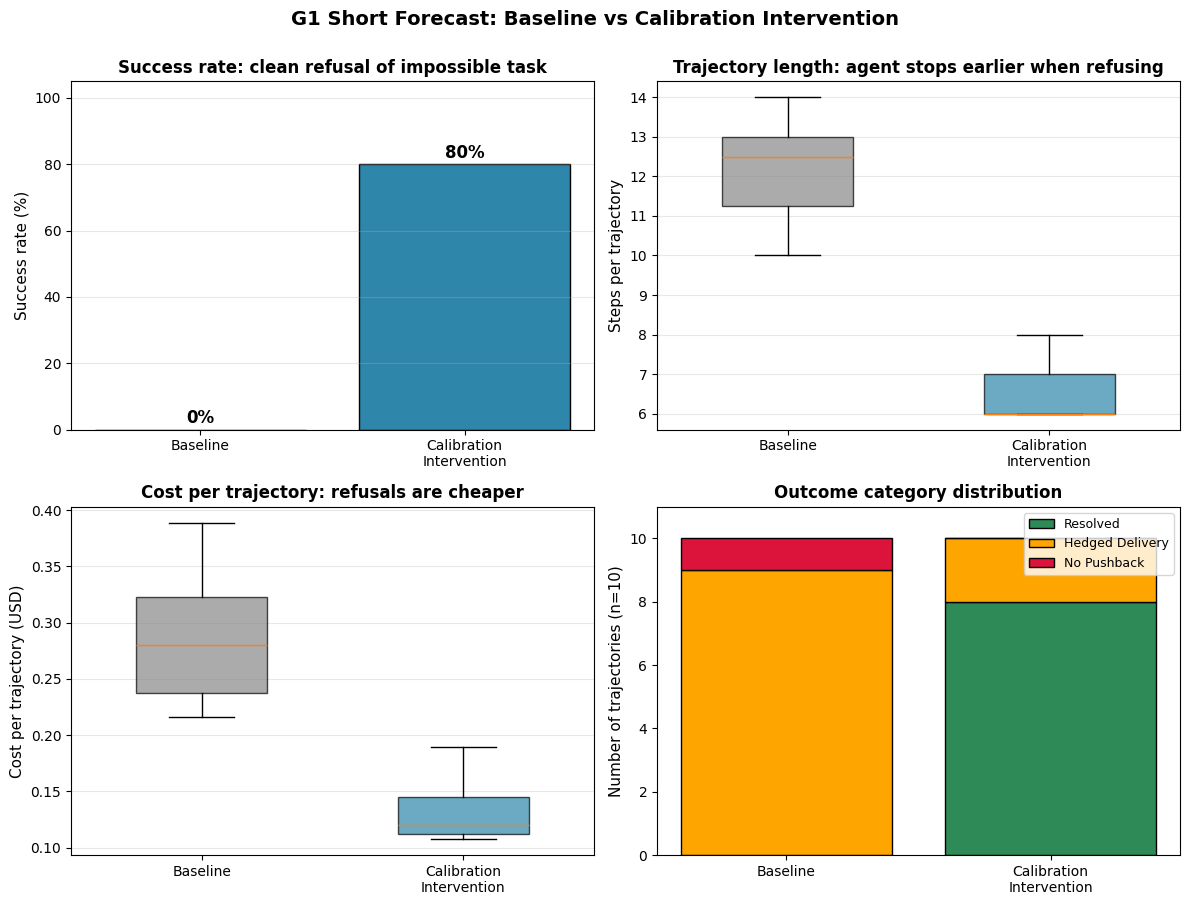

Saved g1_before_after.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

configs_order = ["baseline", "calibration_v1"]
labels_clean = ["Baseline", "Calibration\nIntervention"]
colors = ["#888888", "#2E86AB"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Panel 1: Success rate
ax = axes[0, 0]
success_rates = [g1[g1["config_name"] == c]["success"].mean() * 100 
                 for c in configs_order]
bars = ax.bar(labels_clean, success_rates, color=colors, edgecolor='black')
ax.set_ylabel("Success rate (%)", fontsize=11)
ax.set_title("Success rate: clean refusal of impossible task", fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
for bar, rate in zip(bars, success_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{rate:.0f}%", ha='center', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel 2: Steps (boxplot)
ax = axes[0, 1]
data_steps = [g1[g1["config_name"] == c]["total_steps"].values for c in configs_order]
bp = ax.boxplot(data_steps, labels=labels_clean, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Steps per trajectory", fontsize=11)
ax.set_title("Trajectory length: agent stops earlier when refusing", fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel 3: Cost (boxplot)
ax = axes[1, 0]
data_cost = [g1[g1["config_name"] == c]["cost_usd"].values for c in configs_order]
bp = ax.boxplot(data_cost, labels=labels_clean, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Cost per trajectory (USD)", fontsize=11)
ax.set_title("Cost per trajectory: refusals are cheaper", fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel 4: Outcome category breakdown (stacked bar)
ax = axes[1, 1]
outcome_cats = ["Resolved", "Hedged Delivery", "No Pushback"]
data = pd.DataFrame({
    cat: [(g1[g1["config_name"] == cfg]["outcome_category"] == cat).sum()
          for cfg in configs_order]
    for cat in outcome_cats
}, index=labels_clean)
cat_colors = {"Resolved": "#2E8B57", "Hedged Delivery": "#FFA500",
              "No Pushback": "#DC143C"}
bottom = np.zeros(len(configs_order))
for cat in outcome_cats:
    ax.bar(labels_clean, data[cat].values, bottom=bottom,
           label=cat, color=cat_colors[cat], edgecolor='black')
    bottom += data[cat].values
ax.set_ylabel("Number of trajectories (n=10)", fontsize=11)
ax.set_title("Outcome category distribution", fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 11)

plt.suptitle("G1 Short Forecast: Baseline vs Calibration Intervention",
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("g1_before_after.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved g1_before_after.png")

#### Animated charts

In [8]:
from animated_charts import build_all
from phase_scoring import score_w4_full_batch

# Make sure df_baseline_w4 is loaded
df_baseline_w4 = score_w4_full_batch("baseline")

# Build all three (df should be your full aggregate from earlier)
fig1, fig2, fig3 = build_all(df, df_baseline_w4)

# View any of them inline:
fig1.show()
fig2.show()
fig3.show()

Building chart 1: cost accumulation...
  Saved chart1_cost_accumulation.html
Building chart 2: artifact variance...
  Saved chart2_artifact_variance.html
Building chart 3: phase waterfall...
  Saved chart3_phase_waterfall.html


/var/folders/rm/lh7307zx1q56mhxch_gk4j4w0000gn/T/ipykernel_58486/3360956737.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(w_data, labels=w_labels, patch_artist=True, widths=0.6,
/var/folders/rm/lh7307zx1q56mhxch_gk4j4w0000gn/T/ipykernel_58486/3360956737.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(g_data, labels=g_labels, patch_artist=True, widths=0.6,


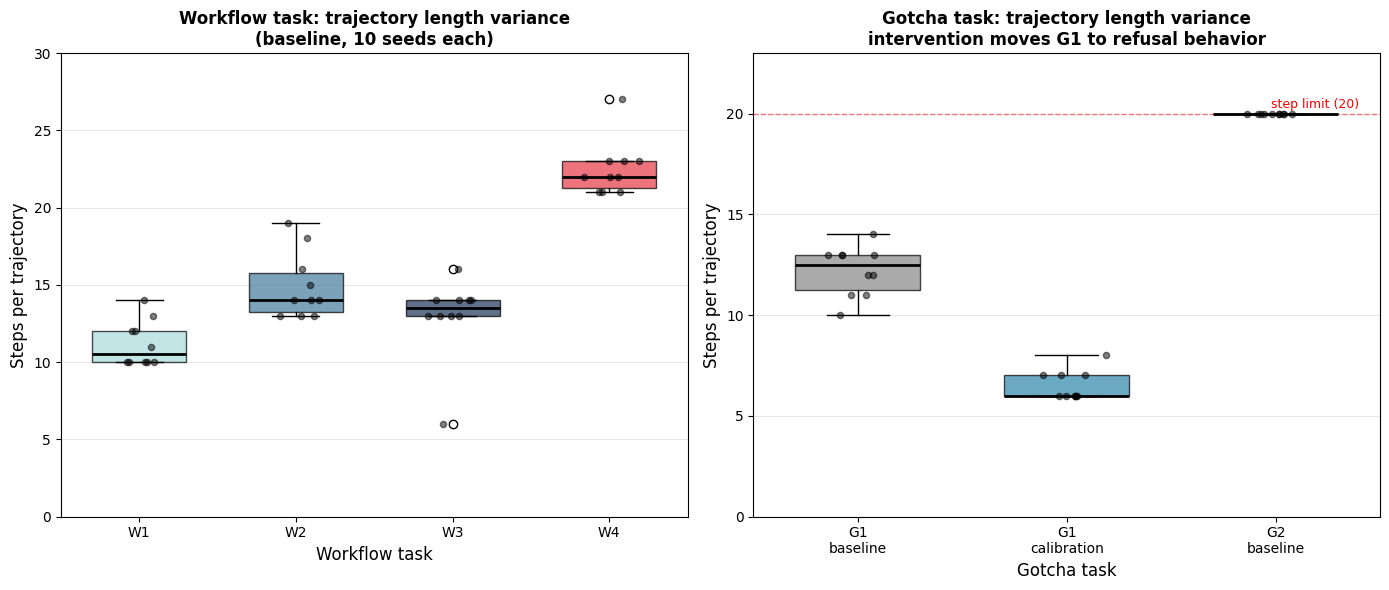

Saved trajectory_variance.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Pull from your aggregated df
w_tasks = ["W1_sales_report", "W2_segmentation", 
           "W3_anomaly_investigation", "W4_campaign_analysis"]
g_tasks = ["G1_short_forecast", "G2_campaigns"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Panel 1: Workflow tasks (baseline) ----
ax = axes[0]
w_data = []
w_labels = []
for task in w_tasks:
    steps = df[(df["task_id"] == task) & 
               (df["config_name"] == "baseline")]["total_steps"].values
    w_data.append(steps)
    w_labels.append(task.split("_")[0])  # just "W1", "W2", etc.

bp = ax.boxplot(w_data, labels=w_labels, patch_artist=True, widths=0.6,
                medianprops=dict(color="black", linewidth=2),
                showfliers=True)
# Color workflows in a gradient
colors = ["#A8DADC", "#457B9D", "#1D3557", "#E63946"]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Overlay individual points (jittered) for transparency
for i, steps in enumerate(w_data):
    x_jitter = np.random.normal(i + 1, 0.08, size=len(steps))
    ax.scatter(x_jitter, steps, alpha=0.5, color='black', s=20, zorder=3)

ax.set_ylabel("Steps per trajectory", fontsize=12)
ax.set_xlabel("Workflow task", fontsize=12)
ax.set_title("Workflow task: trajectory length variance\n(baseline, 10 seeds each)",
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max([max(d) for d in w_data]) + 3)

# ---- Panel 2: Gotcha tasks (baseline vs calibration_v1 for G1) ----
ax = axes[1]
g_data = []
g_labels = []
g_colors = []

# G1 baseline
g1_base = df[(df["task_id"] == "G1_short_forecast") & 
             (df["config_name"] == "baseline")]["total_steps"].values
g_data.append(g1_base)
g_labels.append("G1\nbaseline")
g_colors.append("#888888")

# G1 calibration
g1_calib = df[(df["task_id"] == "G1_short_forecast") & 
              (df["config_name"] == "calibration_v1")]["total_steps"].values
g_data.append(g1_calib)
g_labels.append("G1\ncalibration")
g_colors.append("#2E86AB")

# G2 baseline
g2_base = df[(df["task_id"] == "G2_campaigns") & 
             (df["config_name"] == "baseline")]["total_steps"].values
g_data.append(g2_base)
g_labels.append("G2\nbaseline")
g_colors.append("#A23B72")

bp = ax.boxplot(g_data, labels=g_labels, patch_artist=True, widths=0.6,
                medianprops=dict(color="black", linewidth=2),
                showfliers=True)
for patch, color in zip(bp['boxes'], g_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Overlay jittered points
for i, steps in enumerate(g_data):
    x_jitter = np.random.normal(i + 1, 0.08, size=len(steps))
    ax.scatter(x_jitter, steps, alpha=0.5, color='black', s=20, zorder=3)

# Annotate G2 hitting the step limit
ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.text(3.4, 20.3, "step limit (20)", fontsize=9, color='red', ha='right')

ax.set_ylabel("Steps per trajectory", fontsize=12)
ax.set_xlabel("Gotcha task", fontsize=12)
ax.set_title("Gotcha task: trajectory length variance\nintervention moves G1 to refusal behavior",
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 23)

plt.tight_layout()
plt.savefig("trajectory_variance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved trajectory_variance.png")

In [10]:
print("=== Workflow task variance ===")
for task in w_tasks:
    steps = df[(df["task_id"] == task) & 
               (df["config_name"] == "baseline")]["total_steps"]
    print(f"  {task}: median={steps.median():.0f}, "
          f"std={steps.std():.1f}, range={steps.min()}-{steps.max()}")

print("\n=== Gotcha task variance ===")
for task in g_tasks:
    steps = df[(df["task_id"] == task) & 
               (df["config_name"] == "baseline")]["total_steps"]
    print(f"  {task} baseline: median={steps.median():.0f}, "
          f"std={steps.std():.1f}, range={steps.min()}-{steps.max()}")

g1_c = df[(df["task_id"] == "G1_short_forecast") & 
          (df["config_name"] == "calibration_v1")]["total_steps"]
print(f"  G1_short_forecast calibration: median={g1_c.median():.0f}, "
      f"std={g1_c.std():.1f}, range={g1_c.min()}-{g1_c.max()}")

=== Workflow task variance ===
  W1_sales_report: median=10, std=1.5, range=10-14
  W2_segmentation: median=14, std=2.1, range=13-19
  W3_anomaly_investigation: median=14, std=2.6, range=6-16
  W4_campaign_analysis: median=22, std=1.8, range=21-27

=== Gotcha task variance ===
  G1_short_forecast baseline: median=12, std=1.2, range=10-14
  G2_campaigns baseline: median=20, std=0.0, range=20-20
  G1_short_forecast calibration: median=6, std=0.7, range=6-8


Smoke test for scoring

In [1]:
from pathlib import Path
from scoring import score_trajectory_file
from tasks import get_task

# Score all three smoke-test trajectories
runs = [
    ("T1_top_region", "baseline__T1_top_region__seed0"),
    ("T6_median_2023_spend", "baseline__T6_median_2023_spend__seed0"),
    ("W3_anomaly_investigation", "baseline__W3_anomaly_investigation__seed0"),
]

for task_id, run_dir in runs:
    task = get_task(task_id)
    json_path = Path("runs") / run_dir / "trajectory.json"
    score, metrics = score_trajectory_file(json_path, task)

    print("=" * 70)
    print(f"{task_id}")
    print("=" * 70)
    print(f"  Success: {score.success}")
    print(f"  Extracted answer: {score.extracted_answer}")
    print(f"  Reason: {score.score_reason}")
    if score.artifact_results:
        print(f"  Artifacts: {score.artifact_results}")
    print(f"  ----------")
    print(f"  Steps: {metrics.total_steps} "
          f"({metrics.n_tool_calls} tool calls, "
          f"{metrics.n_reasoning_only_steps} reasoning-only)")
    print(f"  Tokens: {metrics.total_input_tokens} in / "
          f"{metrics.total_output_tokens} out "
          f"({metrics.tokens_per_step:.0f} per step)")
    print(f"  Duration: {metrics.total_duration_seconds:.1f}s")
    print(f"  Errors: {metrics.n_errors} ({dict(metrics.error_types)})")
    print(f"  Encountered error: {metrics.encountered_error}")
    print(f"  Consecutive error pairs: {metrics.consecutive_error_pairs}")
    print(f"  Redundancy: {metrics.n_redundant_calls}/{metrics.n_tool_calls} "
          f"({metrics.redundancy_rate:.0%})")
    print(f"  Hit max steps: {metrics.hit_max_steps}")
    print()

T1_top_region
  Success: True
  Extracted answer: based on my analysis of the sales.csv data, **west** is the region with the highest total revenue this year (2024).

the west region generated $3,423,289.41 in total revenue, which is significantly hi
  Reason: Matched expected answer 'west'
  ----------
  Steps: 4 (3 tool calls, 1 reasoning-only)
  Tokens: 5059 in / 607 out (1416 per step)
  Duration: 11.9s
  Errors: 0 ({})
  Encountered error: False
  Consecutive error pairs: 0
  Redundancy: 0/3 (0%)
  Hit max steps: False

T6_median_2023_spend
  Success: True
  Extracted answer: 7.99
  Reason: Extracted 7.99, expected 7.7 ± 5.0. Within tolerance.
  ----------
  Steps: 11 (10 tool calls, 1 reasoning-only)
  Tokens: 49113 in / 2093 out (4655 per step)
  Duration: 42.7s
  Errors: 2 ({'ValueError': 1, 'DateParseError': 1})
  Encountered error: True
  Consecutive error pairs: 1
  Redundancy: 0/10 (0%)
  Hit max steps: False

W3_anomaly_investigation
  Success: True
  Extracted answer: 1/1

Actual answers

In [2]:
"""
Ground-truth calibration for Q&A tasks.

For each Q&A task, computes the answer a careful human analyst would produce
given the data. Use the printed results to update `tasks.py` with verified
expected answers and reasonable tolerances.
"""

import pandas as pd
import numpy as np

print("=" * 70)
print("GROUND-TRUTH CALIBRATION FOR Q&A TASKS")
print("=" * 70)

# ============================================================
# T1: Which region had the highest total revenue this year?
# ============================================================
print("\n" + "=" * 70)
print("T1: Highest total revenue by region")
print("=" * 70)

sales = pd.read_csv("data/sales.csv")
revenue_by_region = sales.groupby("region")["revenue"].sum().sort_values(ascending=False)
print(revenue_by_region)
print(f"\n→ Top region: {revenue_by_region.index[0]}")
print(f"→ Margin over runner-up: ${revenue_by_region.iloc[0] - revenue_by_region.iloc[1]:,.0f}")
print(f"\nRECOMMENDED: _expected_answer='West', tolerance='exact_match'")


# ============================================================
# T4: Average monthly spend of active premium users
# ============================================================
print("\n" + "=" * 70)
print("T4: Avg monthly spend, active premium users")
print("=" * 70)

users = pd.read_csv("data/users.csv")

# Filter: active AND premium AND non-null spend AND non-negative spend
# (a careful analyst would exclude both NaN and negative spend)
filtered = users[
    (users["is_active"] == True)
    & (users["plan_tier"] == "premium")
    & (users["monthly_spend"].notna())
    & (users["monthly_spend"] >= 0)
]
print(f"Population: {len(filtered)} active premium users with valid spend")
print(f"Mean spend: ${filtered['monthly_spend'].mean():.2f}")
print(f"Median spend: ${filtered['monthly_spend'].median():.2f}")
print(f"Std: ${filtered['monthly_spend'].std():.2f}")

# Tolerance: agent might or might not filter NaN/negative the same way.
# Compute a range of plausible answers.
unfiltered_mean = users[
    (users["is_active"] == True) & (users["plan_tier"] == "premium")
]["monthly_spend"].mean()
print(f"\nMean WITHOUT excluding negatives (naive): ${unfiltered_mean:.2f}")
print(f"\nRECOMMENDED: _expected_answer='{filtered['monthly_spend'].mean():.1f}', "
      f"tolerance='±$10'")


# ============================================================
# T5: Country with the highest user count
# ============================================================
print("\n" + "=" * 70)
print("T5: Top country by user count")
print("=" * 70)

# Without normalization (the wrong answer)
raw_counts = users["country"].value_counts()
print("WITHOUT normalization (raw counts):")
print(raw_counts.head())

# With normalization (the right answer)
country_normalize = {
    "United States": "US",
    "United Kingdom": "UK",
    "CAN": "Canada",
    "I$NDA": "India",
}
users_norm = users.copy()
users_norm["country_normalized"] = users_norm["country"].replace(country_normalize)
norm_counts = users_norm["country_normalized"].value_counts()
print("\nWITH normalization:")
print(norm_counts.head())

print(f"\nNaive answer (alphabetical first US variant): {raw_counts.index[0]}")
print(f"Correct answer: {norm_counts.index[0]}")
print(f"\nRECOMMENDED: _expected_answer accepts 'US' or 'United States' "
      f"(both refer to the same country)")


# ============================================================
# T6: Median monthly spend, 2023 signups, excluding negatives
# ============================================================
print("\n" + "=" * 70)
print("T6: Median spend, 2023 signups, excluding negatives")
print("=" * 70)

# Parse dates carefully — let pandas handle the mixed formats
users["signup_date_parsed"] = pd.to_datetime(
    users["signup_date"], errors="coerce", format="mixed"
)
print(f"Date parse failures (will be excluded): "
      f"{users['signup_date_parsed'].isna().sum()}")

# Filter: signed up in 2023, spend is not negative, spend is not null
in_2023_strict = users[
    (users["signup_date_parsed"].dt.year == 2023)
    & (users["monthly_spend"] >= 0)
    & (users["monthly_spend"].notna())
]
print(f"\nStrict interpretation (well-parsed 2023, non-null, non-negative spend):")
print(f"  Population: {len(in_2023_strict)}")
print(f"  Median: ${in_2023_strict['monthly_spend'].median():.2f}")
print(f"  Mean: ${in_2023_strict['monthly_spend'].mean():.2f}")
print(f"  Tier distribution:")
print(in_2023_strict["plan_tier"].value_counts())

# Alternative: include NaN in "exclude negatives" (slightly different read)
in_2023_lenient = users[
    (users["signup_date_parsed"].dt.year == 2023)
    & ~(users["monthly_spend"] < 0)  # excludes negative; keeps NaN
]
print(f"\nLenient interpretation (NaN kept, but they'll be dropped by median anyway):")
print(f"  Median: ${in_2023_lenient['monthly_spend'].median():.2f}")

median_value = in_2023_strict['monthly_spend'].median()
print(f"\nRECOMMENDED: _expected_answer='{median_value:.1f}', tolerance='±$5'")
print(f"  (Tolerance accounts for differences in NaN/date handling)")


# ============================================================
# T8: Sensor with highest temperature std
# ============================================================
print("\n" + "=" * 70)
print("T8: Sensor with highest temperature variance")
print("=" * 70)

sensors = pd.read_csv("data/sensors.csv")

# Careful: exclude error readings before computing std
sensors_clean = sensors[sensors["status"] == "ok"]
std_by_sensor = sensors_clean.groupby("sensor_id")["temperature"].std().sort_values(
    ascending=False
)
print("Std dev by sensor (excluding 'error' status):")
print(std_by_sensor)
print(f"\nTop sensor: {std_by_sensor.index[0]}")
print(f"Margin over runner-up: {std_by_sensor.iloc[0] - std_by_sensor.iloc[1]:.2f}°C")

# Sanity: also check including error readings
std_all = sensors.groupby("sensor_id")["temperature"].std().sort_values(
    ascending=False
)
print(f"\n(Sanity check: std including error readings — top is still "
      f"{std_all.index[0]})")

print(f"\nRECOMMENDED: _expected_answer='sensor_3', tolerance='exact_match'")


# ============================================================
# T9: Average order total for German customers
# ============================================================
print("\n" + "=" * 70)
print("T9: Avg order total, German customers (in USD)")
print("=" * 70)

orders = pd.read_csv("data/orders.csv")
customers = pd.read_csv("data/customers.csv")

# Normalize Germany variants
germany_variants = ["Germany", "DE", "Deutschland"]
customers["country_norm"] = customers["country"].apply(
    lambda c: "Germany" if c in germany_variants else c
)
print(f"German customers (after normalization): "
      f"{(customers['country_norm'] == 'Germany').sum()}")
print(f"  Variants found in data: "
      f"{customers[customers['country_norm']=='Germany']['country'].value_counts().to_dict()}")

# Filter: German customers, exclude test accounts
german_customers = customers[
    (customers["country_norm"] == "Germany")
    & (customers["is_test_account"] == False)
]
print(f"German customers excluding test accounts: {len(german_customers)}")

# Get their orders
german_orders = orders[orders["customer_id"].isin(german_customers["customer_id"])]
print(f"Total orders from German customers: {len(german_orders)}")

# Currency conversion (EUR → USD)
EUR_TO_USD = 1.08
print(f"\nUsing EUR → USD rate of {EUR_TO_USD}")

# Filter to completed orders only
completed_german = german_orders[german_orders["status"] == "completed"]
print(f"Completed orders only: {len(completed_german)}")

# Convert total_local to USD (these orders are in EUR)
completed_german["total_usd"] = completed_german["total_local"] * EUR_TO_USD

print(f"\nResults:")
print(f"  Avg order total (USD): ${completed_german['total_usd'].mean():.2f}")
print(f"  Median order total (USD): ${completed_german['total_usd'].median():.2f}")

# Alternative: naive answer (no currency conversion, no status filter)
naive_avg = orders[orders["customer_id"].isin(
    customers[customers["country"].isin(germany_variants)]["customer_id"]
)]["total_local"].mean()
print(f"\n  Naive answer (no currency conv, no status filter): {naive_avg:.2f}")
print(f"  (This is what a careless agent will produce)")

correct_answer = completed_german["total_usd"].mean()
print(f"\nRECOMMENDED: _expected_answer='{correct_answer:.0f}', "
      f"tolerance='±$30' (wide because many subtle ways to be off)")


# ============================================================
# Summary
# ============================================================
print("\n" + "=" * 70)
print("CALIBRATION SUMMARY")
print("=" * 70)
print("""
Updates to make in tasks.py:

T1: _expected_answer='West'                  (exact match)
T4: _expected_answer='[see above]'            (±$10)
T5: _expected_answer='US'                     (accept 'US' or 'United States')
T6: _expected_answer='[see above]'            (±$5)
T8: _expected_answer='sensor_3'               (exact match)
T9: _expected_answer='[see above]'            (±$30)

These tolerances reflect that even competent agents can land slightly off
the strict-interpretation answer due to legitimate differences in handling
ambiguous data quality issues (NaN, mixed formats, currency, etc.).
""")

GROUND-TRUTH CALIBRATION FOR Q&A TASKS

T1: Highest total revenue by region
region
West     3423289.41
East     2675407.21
South    2559390.94
North    2248110.87
Name: revenue, dtype: float64

→ Top region: West
→ Margin over runner-up: $747,882

RECOMMENDED: _expected_answer='West', tolerance='exact_match'

T4: Avg monthly spend, active premium users
Population: 102 active premium users with valid spend
Mean spend: $61.96
Median spend: $62.05
Std: $17.98

Mean WITHOUT excluding negatives (naive): $59.61

RECOMMENDED: _expected_answer='62.0', tolerance='±$10'

T5: Top country by user count
WITHOUT normalization (raw counts):
country
United States    291
US               287
UK                78
Australia         76
Canada            75
Name: count, dtype: int64

WITH normalization:
country_normalized
US           578
UK           146
Canada        84
India         76
Australia     76
Name: count, dtype: int64

Naive answer (alphabetical first US variant): United States
Correct answer:

/var/folders/rm/lh7307zx1q56mhxch_gk4j4w0000gn/T/ipykernel_2888/2210778170.py:203: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_german["total_usd"] = completed_german["total_local"] * EUR_TO_USD


In [3]:
# Smoke test: run one task with the baseline config, one seed.
# This verifies the full pipeline: prompt construction, API calls,
# tool execution, sandboxing, logging.

from agent import run_agent, BASELINE_CONFIG
from tasks import get_task

task = get_task("T1_top_region")  # easiest task — should work
traj = run_agent(task, BASELINE_CONFIG, seed=0)

print(f"Task: {traj.task_id}")
print(f"Total steps: {len(traj.steps)}")
print(f"Total tokens: {traj.total_input_tokens} in, {traj.total_output_tokens} out")
print(f"Duration: {traj.end_time - traj.start_time:.1f}s")
print(f"Artifacts created: {traj.artifacts_created}")
print(f"Harness error: {traj.harness_error}")
print()
print(f"Final answer:\n{traj.final_answer}")

Task: T1_top_region
Total steps: 4
Total tokens: 5059 in, 607 out
Duration: 11.9s
Artifacts created: []
Harness error: None

Final answer:
Based on my analysis of the sales.csv data, **West** is the region with the highest total revenue this year (2024).

The West region generated $3,423,289.41 in total revenue, which is significantly higher than the other regions:
- West: $3,423,289.41
- East: $2,675,407.21
- South: $2,559,390.94
- North: $2,248,110.87

**Final Answer: West**


In [4]:
import json
from pathlib import Path

# Load the saved trajectory
log_path = Path("runs") / "baseline__T1_top_region__seed0" / "trajectory.json"
with open(log_path) as f:
    log = json.load(f)

# Walk through each step
for step in log["steps"]:
    print(f"\n--- Step {step['step_index']} ---")
    print(f"Tokens: {step['input_tokens']} in, {step['output_tokens']} out")
    print(f"Stop reason: {step['stop_reason']}")
    print(f"Duration: {step['duration_seconds']:.2f}s")
    if step['response_text']:
        print(f"Response text (first 200 chars): {step['response_text'][:200]}")
    if step['tool_call']:
        code = step['tool_call']['input'].get('code', '')
        print(f"Tool call: python")
        print(f"  Code (first 200 chars):\n  {code[:200]}")
    if step['tool_result']:
        print(f"Tool result: error={step['tool_result']['error']}, "
              f"output (first 200 chars): {str(step['tool_result']['output'])[:200]}")


--- Step 0 ---
Tokens: 816 in, 156 out
Stop reason: tool_use
Duration: 2.50s
Response text (first 200 chars): I'll help you analyze the sales data to find which region had the highest total revenue this year.
Tool call: python
  Code (first 200 chars):
  
import pandas as pd
import numpy as np

# Load the sales data
df = pd.read_csv('sales.csv')

# Display first few rows to understand the structure
print("First few rows of the data:")
print(df.head())
Tool result: error=False, output (first 200 chars): First few rows of the data:
         date region     category   revenue  units_sold
0  2024-01-01  North  Electronics  85279.81        1466
1  2024-01-01  North      Apparel  61006.33         925
2  2

--- Step 1 ---
Tokens: 1157 in, 166 out
Stop reason: tool_use
Duration: 3.29s
Tool call: python
  Code (first 200 chars):
  
# Check the date range to understand what "this year" means
print("Date range in the data:")
print(df['date'].min(), "to", df['date'].max())

# Check unique regions

In [5]:
# Smoke-test on a harder Q&A task and a workflow task
# This validates: dirty data handling, file artifact creation, longer trajectories

# T6: median 2023 spend — exercises dirty dates, NaN spend, negative values
print("=" * 60)
print("Running T6 (median 2023 spend)...")
print("=" * 60)
task_t6 = get_task("T6_median_2023_spend")
traj_t6 = run_agent(task_t6, BASELINE_CONFIG, seed=0)
print(f"Steps: {len(traj_t6.steps)}")
print(f"Tokens: {traj_t6.total_input_tokens + traj_t6.total_output_tokens}")
print(f"Duration: {traj_t6.end_time - traj_t6.start_time:.1f}s")
print(f"Errors encountered: {sum(1 for s in traj_t6.steps if s.tool_result and s.tool_result.get('error'))}")
print(f"Harness error: {traj_t6.harness_error}")
print(f"\nFinal answer:\n{traj_t6.final_answer[:500]}")
print()



Running T6 (median 2023 spend)...
Steps: 11
Tokens: 51206
Duration: 42.7s
Errors encountered: 2
Harness error: None

Final answer:
Perfect! The calculation is confirmed.

**Final Answer: 7.99**

The median monthly spend for users who signed up in 2023, excluding users with negative spend values, is **$7.99**.



In [7]:
import pandas as pd

users = pd.read_csv("data/users.csv")

# Parse dates carefully
users["signup_date_parsed"] = pd.to_datetime(users["signup_date"], errors="coerce")

# Filter 2023 signups, excluding negatives
in_2023 = users[
    (users["signup_date_parsed"].dt.year == 2023)
    & (users["monthly_spend"] >= 0)
    & (users["monthly_spend"].notna())
]

print(f"2023 signups (clean): {len(in_2023)}")
print(f"  by tier:")
print(in_2023["plan_tier"].value_counts())
print()
print(f"Spend stats:")
print(in_2023["monthly_spend"].describe())
print()
print(f"Median: {in_2023['monthly_spend'].median():.2f}")

2023 signups (clean): 298
  by tier:
plan_tier
free          144
basic          86
premium        56
enterprise     12
Name: count, dtype: int64

Spend stats:
count    298.000000
mean      27.482819
std       51.293234
min        0.000000
25%        0.547500
50%        7.990000
75%       26.452500
max      296.370000
Name: monthly_spend, dtype: float64

Median: 7.99


In [6]:
# W3: anomaly investigation — exercises file output, multi-artifact deliverable
print("=" * 60)
print("Running W3 (anomaly investigation)...")
print("=" * 60)
task_w3 = get_task("W3_anomaly_investigation")
traj_w3 = run_agent(task_w3, BASELINE_CONFIG, seed=0)
print(f"Steps: {len(traj_w3.steps)}")
print(f"Tokens: {traj_w3.total_input_tokens + traj_w3.total_output_tokens}")
print(f"Duration: {traj_w3.end_time - traj_w3.start_time:.1f}s")
print(f"Errors encountered: {sum(1 for s in traj_w3.steps if s.tool_result and s.tool_result.get('error'))}")
print(f"Artifacts created: {traj_w3.artifacts_created}")
print(f"Harness error: {traj_w3.harness_error}")
print(f"\nFinal answer:\n{traj_w3.final_answer[:500]}")

Running W3 (anomaly investigation)...
Steps: 13
Tokens: 70946
Duration: 118.4s
Errors encountered: 1
Artifacts created: ['sensor_timeseries.png', 'sensor_anomaly_analysis.png', 'report_anomalies.md']
Harness error: None

Final answer:
Perfect! I have completed the analysis and created the requested deliverables. Here's a summary of my findings:

## Summary

**Problematic Sensor: Sensor 3**

### Key Evidence:
1. **Severe Temperature Drift**: Sensor 3 shows a consistent upward drift of +0.33°C per day, totaling ~10°C over the 30-day period (from ~22°C to ~32°C). This is statistically significant with R² = 0.74 and p-value < 10⁻²⁰⁰.

2. **Excessive Variability**: Standard deviation of 3.38°C compared to ~0.30°C for other sensors
